In [32]:
import torch
import numpy as np

import matplotlib as mpl

# remove top and right axis from plots
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["axes.spines.top"] = False

In [33]:
from sbi import analysis as analysis

# sbi
from sbi import utils as utils
from sbi.inference import NPE, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

from sbi.diagnostics import check_sbc, run_sbc
from sbi.analysis.plot import sbc_rank_plot

### Data

In [34]:
from models.MyLOModel2D import create_time_specs, run_LOModel

Tmax, dt = 2 * np.pi * 10, 0.01
t = create_time_specs(Tmax, dt)
Dx = 0.01

def simulate_LO_model(params):
    simulation = run_LOModel(params.squeeze(), t, dt, Dx=Dx)
    return simulation["x"]

In [35]:
from datasets.MyDataset import Dataset
from torch.utils.data import DataLoader

DATASET_PATH = '/Users/lauragarcialopez/Documents/uni/TFG/06.TFG/codes/data/'

# Load training dataset
train_dataset = Dataset(f"{DATASET_PATH}train_dataset__Dx={str(Dx)}_Tmax={Tmax}.json")
train_loader = DataLoader(train_dataset, batch_size=4000, shuffle=True)

### SBI with pre-trained Autoencoder

In [36]:
from autoencoders.Autoencoder import MyAutoencoder

# For Linear Blocks use 'linear_layers' and specify values {'input_dim', 'output_dim', 'hidden_layers'}
# For Recurrent Blocks use 'recurrent_layers' and specify values {'input_size', 'output_size', 'hidden_sizes'}
# For Convolutional Blocks use 'convolutional_layers' and specify values {'input_channels', 'output_channels', 'hidden_channels', 'kernels'}
# For Transformer Blocks use 'transformer_block' and specify values {}

# Personalize Model
embedding_dim = 4
params = {'encoder' : {'linear_layers' : {'input_dim' : len(t),
                                          'output_dim' : embedding_dim,
                                          'hidden_layers' : [1024, 512, 128, 32]},
                    #    'transformer_block' : {'input_dim' : len(t),
                    #                           'num_heads' : 5,
                    #                           'intrinsic_dim' : 3000,
                    #                           'dropout' : 0.3,
                    #                           'transformer' : 'multihead_attention'},
                      },
          'decoder' : {'linear_layers' : {'input_dim' : embedding_dim,
                                          'output_dim' : len(t),
                                          'hidden_layers' : [32, 128, 512, 1024]}}}

autoencoder = MyAutoencoder(params)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = autoencoder.to(device)

In [37]:
model_num = '054'
MODEL_PATH = f'./trained_models/AE/AE_{model_num}/'
# MODEL_PATH = './trained_models/AE/AE_054/'

# autoencoder.load_state_dict(torch.load('AE.pth')) # Load the weights
autoencoder.load_state_dict(torch.load(f'{MODEL_PATH}AE.pth'))
autoencoder.eval()

/var/folders/m4/cjl7ypxj3m5dgvkmsttj663m0000gn/T/ipykernel_33726/4090434978.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  autoencoder.load_state_dict(torch.load(f'{MOD

MyAutoencoder(
  (encoder): MyEncoder(
    (linear_block): LinearBlock(
      (linear): Sequential(
        (0): Linear(in_features=6285, out_features=1024, bias=True)
        (1): ReLU()
        (2): Linear(in_features=1024, out_features=512, bias=True)
        (3): ReLU()
        (4): Linear(in_features=512, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
        (7): ReLU()
        (8): Linear(in_features=32, out_features=4, bias=True)
      )
    )
  )
  (decoder): MyDecoder(
    (linear_block): LinearBlock(
      (linear): Sequential(
        (0): Linear(in_features=4, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=512, bias=True)
        (5): ReLU()
        (6): Linear(in_features=512, out_features=1024, bias=True)
        (7): ReLU()
        (8): Linear(in_features=1024, out_featu

#### SBI Training

In [38]:
def simulator(params):
    simulation = run_LOModel(params.squeeze(), t, dt, Dx=Dx)
    return autoencoder.encode(simulation["x"].unsqueeze(0)).detach()

In [39]:
prior_min, prior_max = [0.5] * 2, [1.5] * 2

prior = utils.torchutils.BoxUniform(
    low=torch.as_tensor(prior_min), high=torch.as_tensor(prior_max)
)

# Check prior, simulator, consistency
prior, num_parameters, prior_returns_numpy = process_prior(prior)
simulator = process_simulator(simulator, prior, prior_returns_numpy)
check_sbi_inputs(simulator, prior)

In [40]:
inference = NPE(prior=prior)

new_inference = False
if new_inference:
    num_simulations = 4000
    theta, x = simulate_for_sbi(simulator, proposal=prior, num_simulations=num_simulations, num_workers=4)

    inference = inference.append_simulations(theta, x)

    # train the density estimator and build the posterior
    density_estimator = inference.train()

    torch.save(inference._neural_net.state_dict(), f'{MODEL_PATH}SBI.pth')
else:
    theta_0 = prior.sample((10, ))
    x = []
    for theta in theta_0:
        x += [simulate_LO_model(theta)]
    x_0 = torch.stack(x)
    z_0 = autoencoder.encode(x_0.view((10, -1))).detach()

    _ = inference.append_simulations(theta_0, z_0).train(max_num_epochs=0)

    inference._neural_net.load_state_dict(torch.load(f'{MODEL_PATH}SBI.pth'))

posterior = inference.build_posterior()

 Training neural network. Epochs trained: 1

/var/folders/m4/cjl7ypxj3m5dgvkmsttj663m0000gn/T/ipykernel_33726/3598266996.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  inference._neural_net.load_state_dict(torch.

In [41]:
obs_params1, obs_params2 = torch.tensor([[1, 1]]), torch.tensor([[0.75, 0.75]])

obs_trace1 = run_LOModel(obs_params1.squeeze(), t, dt, Dx=Dx)
obs_trace2 = run_LOModel(obs_params2.squeeze(), t, dt, Dx=Dx)

obs1 = autoencoder.encode(obs_trace1['x'].unsqueeze(0)).detach()
obs2 = autoencoder.encode(obs_trace2['x'].unsqueeze(0)).detach()

### Observation 1 - $\theta_1=(1, 1)$

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

/var/folders/m4/cjl7ypxj3m5dgvkmsttj663m0000gn/T/ipykernel_33726/3883884944.py:4: DeprecationWarning: you passed deprecated arguments **kwargs: ['points_offdiag', 'points_colors'], use fig_kwargs instead. We continue calling the deprecated pairplot function
  fig, axes = analysis.pairplot(


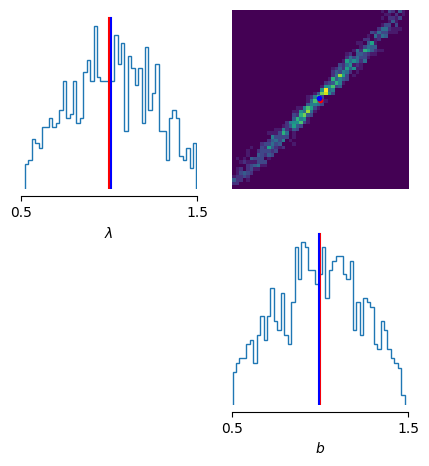

In [42]:
samples1 = posterior.sample((1000, ), x = obs1)
mean_params1 = samples1.mean(axis=0)

fig, axes = analysis.pairplot(
    samples1,
    limits=[[prior_min[ii], prior_max[ii]] for ii in range(len(prior_min))],
    ticks=[[prior_min[ii], prior_max[ii]] for ii in range(len(prior_min))],
    figsize=(5, 5),
    points_offdiag={"markersize": 6},
    points_colors=["r", "b"],
    points=[obs_params1, mean_params1],
    labels=[r'$\lambda$', r'$b$'],
)

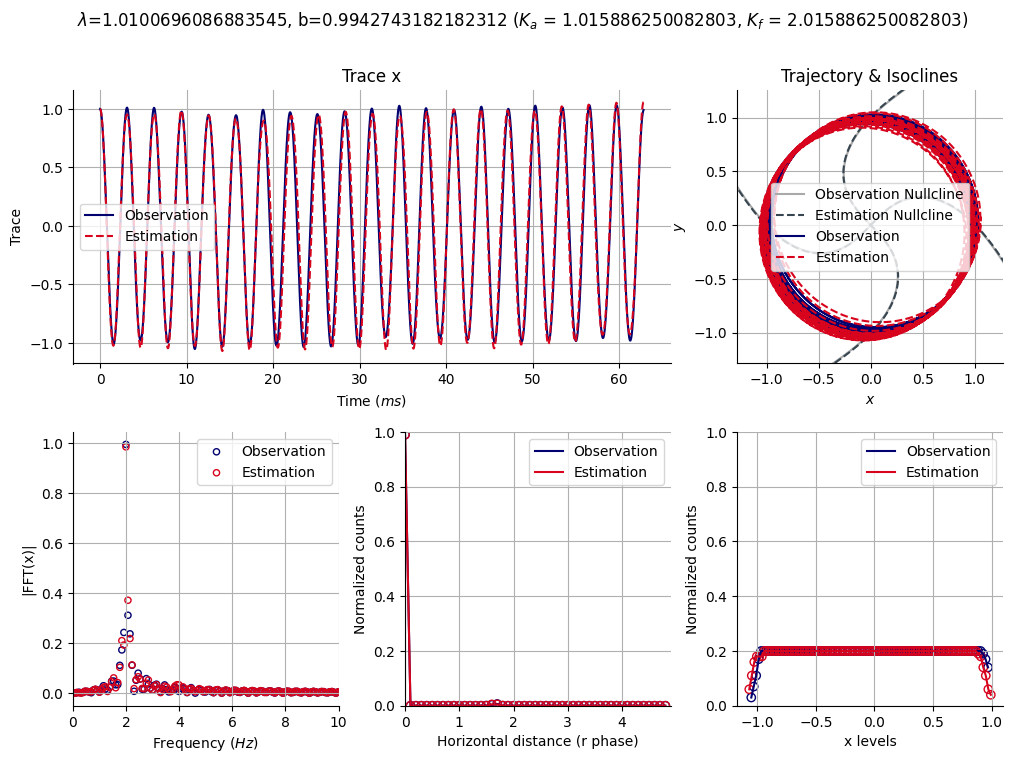

In [43]:
from models.MyLOModel2D import plot_reconstructions

trace1 = run_LOModel(mean_params1, t, dt, Dx=Dx)
plot_reconstructions(obs_trace1, trace1, obs_params1.unsqueeze(0), mean_params1.unsqueeze(0), 'x')

#### Metrics

The Wasserstein Distance for the distribution of the simulation values is 0.016959980874763983
The p-value for the Levene test is 0.0. 
 The Levene test says the variances of the error distributions the variances are different.


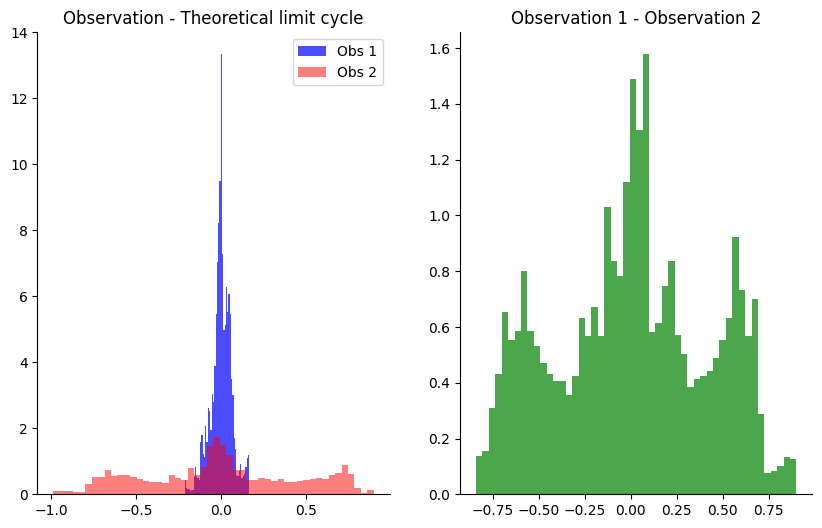

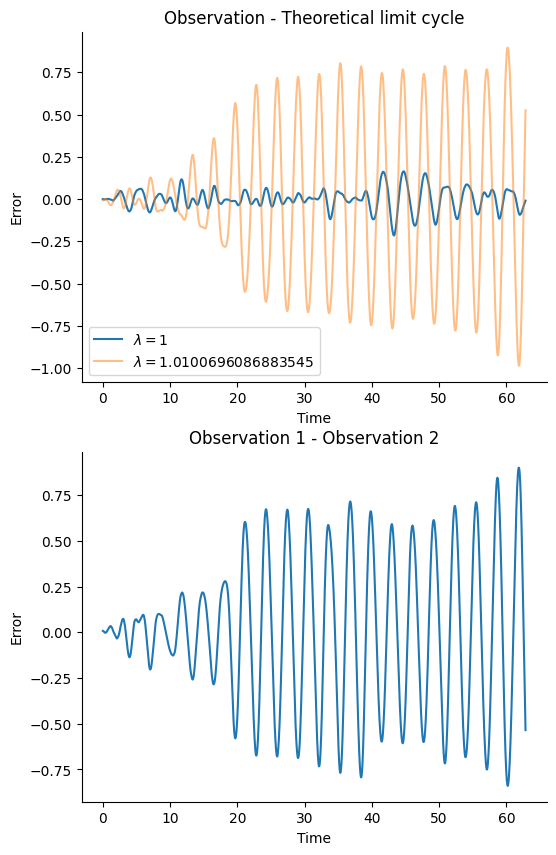

The Wasserstein Distance for the distribution of the error (wrt the ideal sinusoid) values is 0.31190343435049916


In [44]:
from metrics.WassErrDist import WassDist, WassErrDist

print(f"The Wasserstein Distance for the distribution of the simulation values is {WassDist(obs_trace1, trace1)}")
print(f"The Wasserstein Distance for the distribution of the error (wrt the ideal sinusoid) values is {WassErrDist(obs_trace1, trace1, obs_params1.squeeze(), mean_params1, plot=True)}")

### Observation 2 - $\theta_2=(0.75, 0.75)$

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

/var/folders/m4/cjl7ypxj3m5dgvkmsttj663m0000gn/T/ipykernel_33726/1824077530.py:4: DeprecationWarning: you passed deprecated arguments **kwargs: ['points_offdiag', 'points_colors'], use fig_kwargs instead. We continue calling the deprecated pairplot function
  fig, axes = analysis.pairplot(


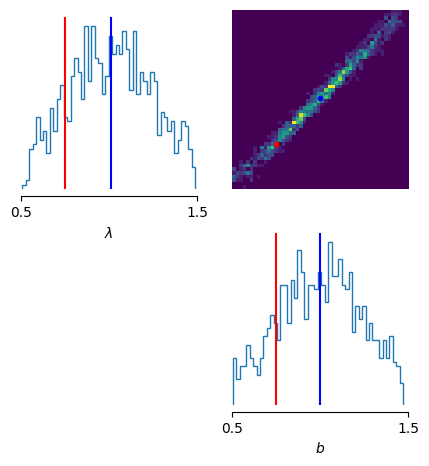

In [45]:
samples2 = posterior.sample((1000, ), x = obs2)
mean_params2 = samples2.mean(axis=0)

fig, axes = analysis.pairplot(
    samples2,
    limits=[[prior_min[ii], prior_max[ii]] for ii in range(len(prior_min))],
    ticks=[[prior_min[ii], prior_max[ii]] for ii in range(len(prior_min))],
    figsize=(5, 5),
    points_offdiag={"markersize": 6},
    points_colors=["r", "b"],
    points=[obs_params2, mean_params2],
    labels=[r'$\lambda$', r'$b$'],
)

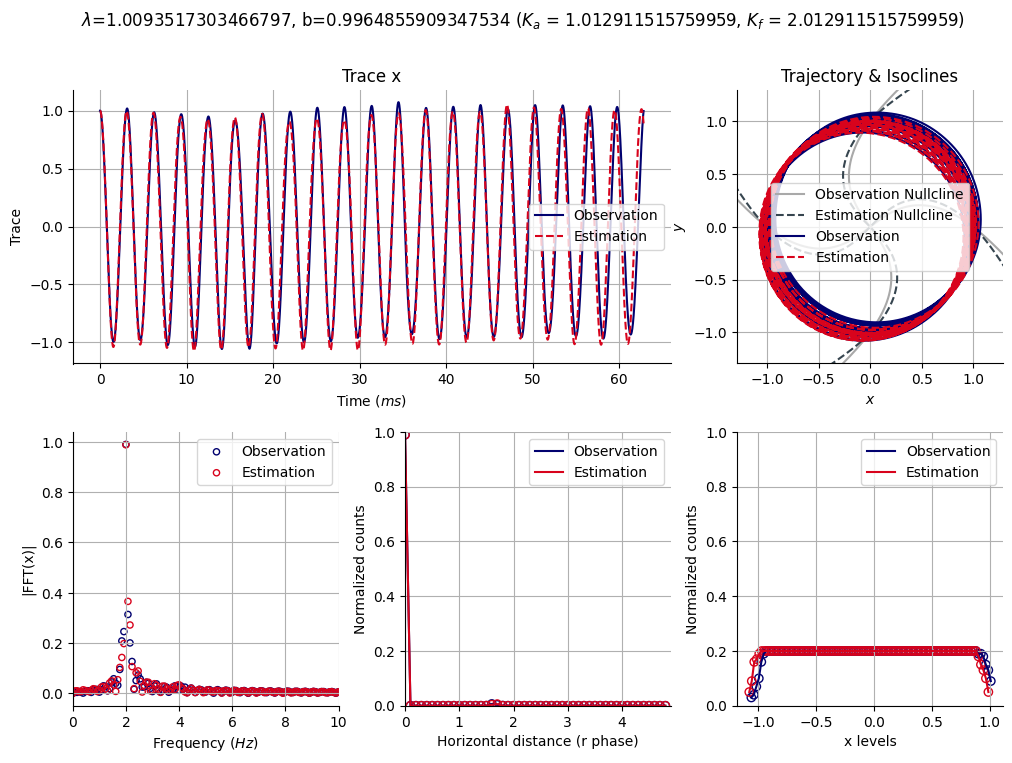

In [46]:
trace2 = run_LOModel(mean_params2, t, dt, Dx=Dx)
plot_reconstructions(obs_trace2, trace2, obs_params2.unsqueeze(0), mean_params2.unsqueeze(0), 'x')

#### Metrics

The Wasserstein Distance for the distribution of the simulation values is 0.030111616942639103
The p-value for the Levene test is 0.0. 
 The Levene test says the variances of the error distributions the variances are different.


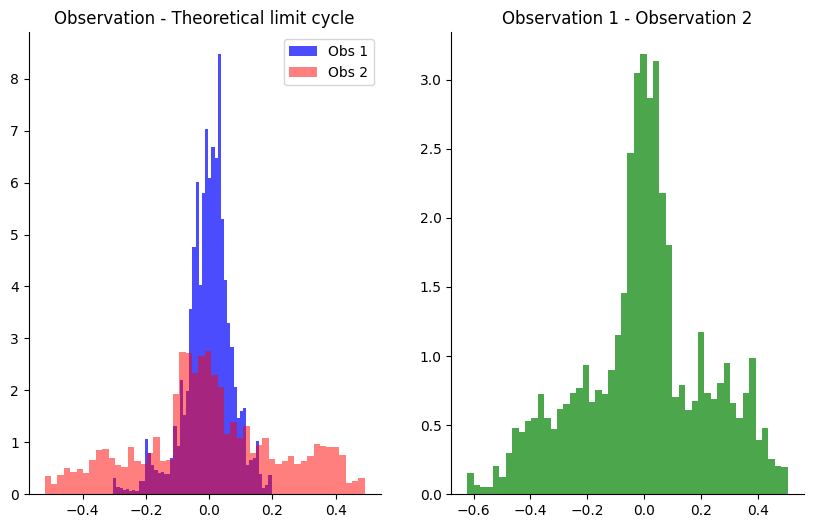

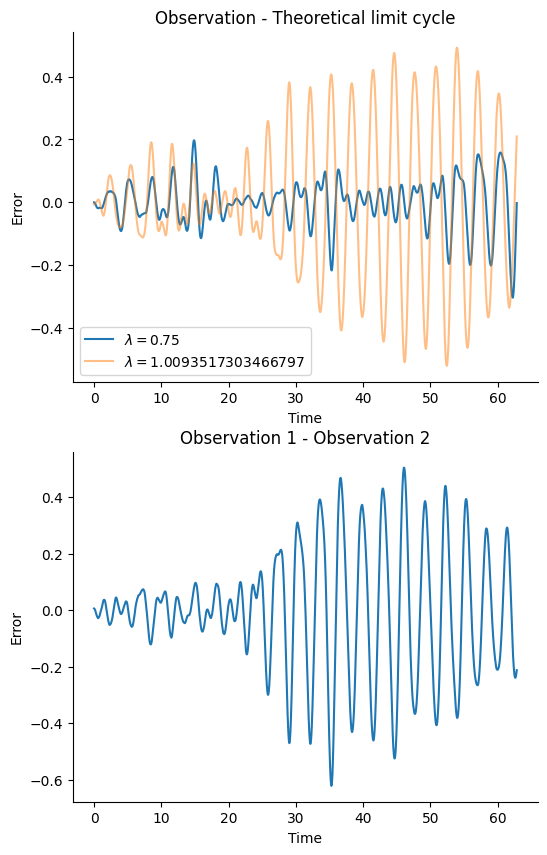

The Wasserstein Distance for the distribution of the error (wrt the ideal sinusoid) values is 0.12061568874581538


In [47]:
print(f"The Wasserstein Distance for the distribution of the simulation values is {WassDist(obs_trace2, trace2)}")
print(f"The Wasserstein Distance for the distribution of the error (wrt the ideal sinusoid) values is {WassErrDist(obs_trace2, trace2, obs_params2.squeeze(), mean_params2, plot=True)}")

### Diagnostics

**Posterior Predictive Checks**

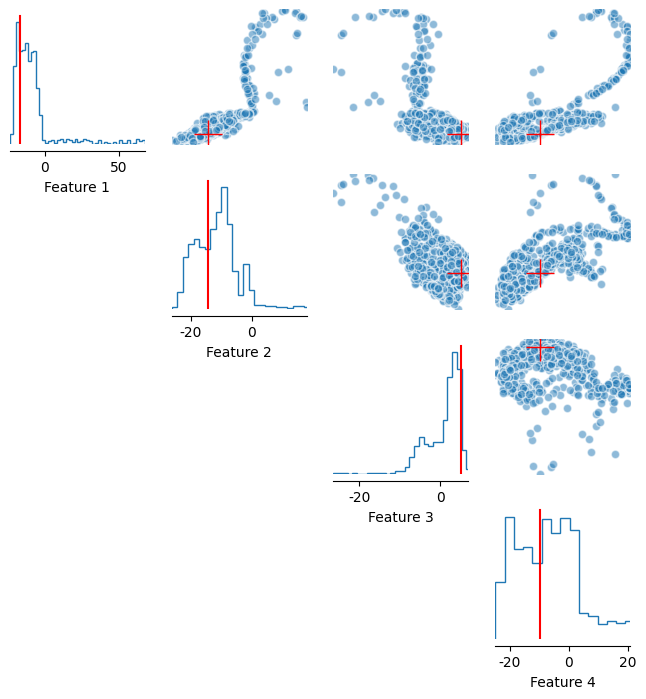

In [48]:
x_pp1 = simulator(samples1).squeeze()

_ = analysis.pairplot(
    samples=x_pp1,
    points=obs1,
    upper="scatter",
    figsize=(8, 8),
    upper_kwargs=dict(marker=".", s=5),
    fig_kwargs=dict(
        points_offdiag=dict(marker="+", markersize=20),
        points_colors="red",
    ),
    labels=[rf"Feature {d+1}" for d in range(embedding_dim)],
)

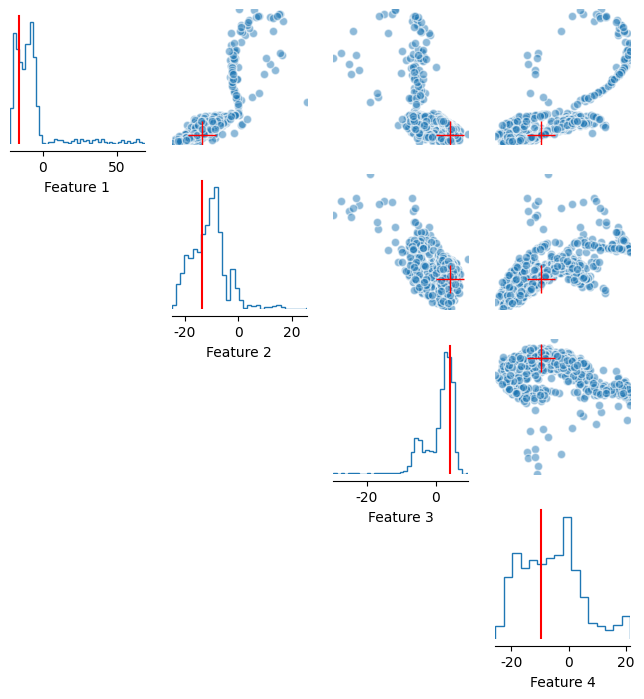

In [49]:
x_pp2 = simulator(samples2).squeeze()

_ = analysis.pairplot(
    samples=x_pp2,
    points=obs2,
    upper="scatter",
    figsize=(8, 8),
    upper_kwargs=dict(marker=".", s=5),
    fig_kwargs=dict(
        points_offdiag=dict(marker="+", markersize=20),
        points_colors="red",
    ),
    labels=[rf"Feature {d+1}" for d in range(embedding_dim)],
)

**Simulation-Based Calibration**

In [ ]:
th_sbc = prior.sample((200, ))
x_sbc = simulator(th_sbc).squeeze()

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating ranks for 200 sbc samples.:   0%|          | 0/200 [00:00<?, ?it/s]

kolmogorov-smirnov p-values 
 check_stats['ks_pvals'] = [4.4069727e-04 2.1051685e-05]
c2st accuracies 
check_stats['c2st_ranks'] = [0.5325 0.5475]
- c2st accuracies check_stats['c2st_dap'] = [0.5475 0.5225]


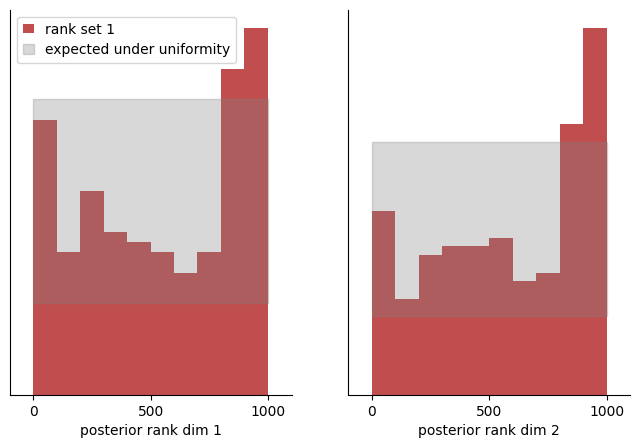

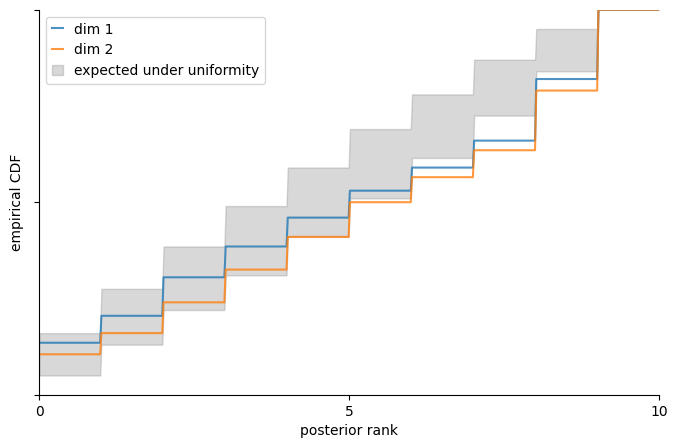

In [54]:
ranks, dap_samples = run_sbc(th_sbc, x_sbc, posterior, num_posterior_samples=1000, num_workers=4)

check_stats = check_sbc(ranks, th_sbc, dap_samples, num_posterior_samples=1000)
print(f"""kolmogorov-smirnov p-values \n check_stats['ks_pvals'] = {check_stats['ks_pvals'].numpy()}""")
print(f"c2st accuracies \ncheck_stats['c2st_ranks'] = {check_stats['c2st_ranks'].numpy()}")
print(f"- c2st accuracies check_stats['c2st_dap'] = {check_stats['c2st_dap'].numpy()}")

f, ax = sbc_rank_plot(ranks=ranks, num_posterior_samples=1000, plot_type="hist", num_bins=None)
f, ax = sbc_rank_plot(ranks, 1000, plot_type="cdf")

In [55]:
# use reduce_fns in order to map the test statistic to only one dimension
ranks, dap_samples = run_sbc(th_sbc, x_sbc, posterior, num_posterior_samples=1000, reduce_fns=posterior.log_prob)
check_stats = check_sbc(ranks, th_sbc, dap_samples, 1000)
print(check_stats)

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating ranks for 200 sbc samples.:   0%|          | 0/200 [00:00<?, ?it/s]

{'ks_pvals': tensor([0.1884]), 'c2st_ranks': tensor([0.4900], dtype=torch.float64), 'c2st_dap': tensor([0.5675, 0.5825], dtype=torch.float64)}
